In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)


In [ ]:
from google.colab import files

uploaded = files.upload()


Saving diabetic_data.csv to diabetic_data.csv


In [ ]:
df = pd.read_csv("diabetic_data.csv")

print("Dataset shape:", df.shape)

df.head()


Dataset shape: (101766, 50)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [ ]:
print("Columns:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isnull().sum())


Columns:
['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'payer_code', 'medical_specialty', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted']

Missing values:
encounter_id                    0
patient_nbr                     0
race                            0
gender                          0
age                 

In [ ]:
age_mapping = {
    "[0-10)": 5,
    "[10-20)": 15,
    "[20-30)": 25,
    "[30-40)": 35,
    "[40-50)": 45,
    "[50-60)": 55,
    "[60-70)": 65,
    "[70-80)": 75,
    "[80-90)": 85,
    "[90-100)": 95
}

df["age"] = df["age"].map(age_mapping)

df[["age"]].head()


,age
0,5
1,15
2,25
3,35
4,45


In [ ]:
df["readmitted_30d"] = (df["readmitted"] == "<30").astype(int)

print(df["readmitted_30d"].value_counts())


readmitted_30d
0    90409
1    11357
Name: count, dtype: int64


In [ ]:
features = [
    "age",
    "time_in_hospital",
    "number_outpatient",
    "number_inpatient",
    "number_emergency"
]

X = df[features]
y = df["readmitted_30d"]

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())


Features:
   age  time_in_hospital  number_outpatient  number_inpatient  \
0    5                 1                  0                 0   
1   15                 3                  0                 0   
2   25                 2                  2                 1   
3   35                 2                  0                 0   
4   45                 1                  0                 0   

   number_emergency  
0                 0  
1                 0  
2                 0  
3                 0  
4                 0  

Target:
0    0
1    0
2    0
3    0
4    0
Name: readmitted_30d, dtype: int64


In [ ]:
X = X.fillna(X.median())

print("Missing values after cleaning:")
print(X.isnull().sum())


Missing values after cleaning:
age                  0
time_in_hospital     0
number_outpatient    0
number_inpatient     0
number_emergency     0
dtype: int64


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)


Training data: (81412, 5)
Testing data: (20354, 5)


In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [ ]:
model = LogisticRegression(
    penalty="l2",
    C=1.0,
    max_iter=1000,
    random_state=42
)


In [ ]:
model.fit(X_train, y_train)

print("Model training completed.")


Model training completed.


In [ ]:
y_prob = model.predict_proba(X_test)[:, 1]

print("First 10 predicted probabilities:")
print(y_prob[:10])


First 10 predicted probabilities:
[0.12257534 0.09073892 0.11188298 0.11181556 0.11609438 0.07718964
 0.08911361 0.08807454 0.25752802 0.1549586 ]


In [ ]:
y_pred = (y_prob >= 0.5).astype(int)

print("First 10 predictions:")
print(y_pred[:10])


First 10 predictions:
[0 0 0 0 0 0 0 0 0 0]


In [ ]:
auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", round(auc, 3))


ROC-AUC Score: 0.639


In [ ]:
print("Classification Report:")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "Not Readmitted",
            "Readmitted"
        ]
    )
)


Classification Report:
                precision    recall  f1-score   support

Not Readmitted       0.89      1.00      0.94     18083
    Readmitted       0.49      0.02      0.03      2271

      accuracy                           0.89     20354
     macro avg       0.69      0.51      0.49     20354
  weighted avg       0.85      0.89      0.84     20354



In [ ]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)


Confusion Matrix:
[[18047    36]
 [ 2236    35]]


In [ ]:
tn, fp, fn, tp = cm.ravel()

print("True Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives :", tp)


True Negatives : 18047
False Positives: 36
False Negatives: 2236
True Positives : 35


In [ ]:
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)

print("Sensitivity:", round(sensitivity, 3))
print("Specificity:", round(specificity, 3))


Sensitivity: 0.015
Specificity: 0.998


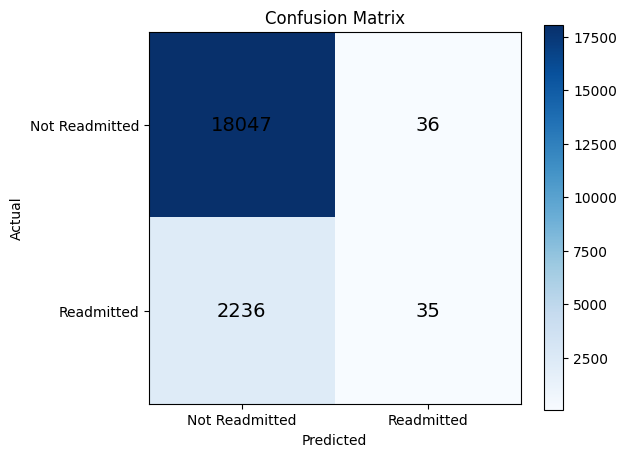

In [ ]:
plt.figure(figsize=(6, 5))

plt.imshow(cm, cmap="Blues")

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks(
    [0, 1],
    ["Not Readmitted", "Readmitted"]
)

plt.yticks(
    [0, 1],
    ["Not Readmitted", "Readmitted"]
)

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center",
            fontsize=14
        )

plt.colorbar()
plt.show()


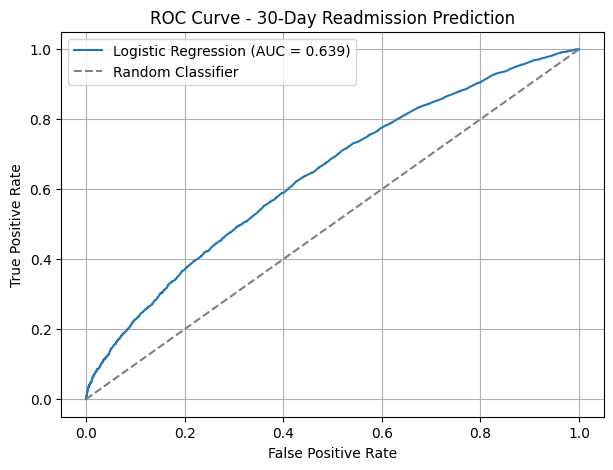

In [ ]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    "--",
    color="gray",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - 30-Day Readmission Prediction")

plt.legend()
plt.grid()

plt.show()


In [ ]:
coefficients = pd.DataFrame({
    "Feature": features,
    "Coefficient": model.coef_[0]
})

coefficients


,Feature,Coefficient
0,age,0.072789
1,time_in_hospital,0.097760
2,number_outpatient,0.004864
3,number_inpatient,0.351781
4,number_emergency,0.032546


In [ ]:
coefficients.sort_values(
    by="Coefficient",
    ascending=False
)


,Feature,Coefficient
3,number_inpatient,0.351781
1,time_in_hospital,0.097760
0,age,0.072789
4,number_emergency,0.032546
2,number_outpatient,0.004864


In [ ]:
print("ROC-AUC:", round(auc, 3))
print("False Positives:", fp)
print("False Negatives:", fn)
print("Sensitivity:", round(sensitivity, 3))
print("Specificity:", round(specificity, 3))


ROC-AUC: 0.639
False Positives: 36
False Negatives: 2236
Sensitivity: 0.015
Specificity: 0.998
